 ### 1. Import libraries

**Mục đích:** Nạp các thư viện cần thiết để xử lý dữ liệu, thực hiện lựa chọn đặc trưng bằng RFECV và giảm chiều dữ liệu (PCA, SVD, LDA).  
**Input:** Thư viện hệ thống `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`.  
**Output:** Môi trường lập trình sẵn sàng cho các bước xử lý và mô hình hóa.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Ẩn các cảnh báo đỏ để notebook sạch đẹp

# Thư viện cho Feature Selection
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.feature_selection import SelectKBest, f_regression, SelectFromModel
from sklearn.linear_model import Lasso

# Thư viện cho Dimensionality Reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

### 2. Read and prepare dataset

**Mục đích:** Đọc dữ liệu, loại bỏ cột định dạng chuỗi (`date`), tách biến mục tiêu và chuẩn hóa tập đặc trưng về cùng thang đo (bắt buộc trước khi giảm chiều). Đồng thời rời rạc hóa (discretize) biến mục tiêu thành 3 nhóm để dùng riêng cho LDA.  
**Input:** File CSV `KAG_energydata_complete.csv`.  
**Output:** Tập đặc trưng đã chuẩn hóa `X_scaled`, biến mục tiêu liên tục `y_continuous` và biến phân loại `y_categorical`.

In [7]:
# Tải dữ liệu
df = pd.read_csv('KAG_cleaned_week1.csv')

# Bỏ cột 'date' vì thuật toán không đọc được dạng chuỗi
# Bỏ cột 'Appliances' để tạo tập đặc trưng X
X = df.drop(columns=['date', 'Appliances'])

# Biến mục tiêu liên tục cho RFECV
y_continuous = df['Appliances']

# Biến mục tiêu phân loại (3 nhóm) dành riêng cho LDA
y_categorical = pd.qcut(y_continuous, q=3, labels=[0, 1, 2])

# Chuẩn hóa X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Kích thước X ban đầu:", X_scaled.shape)

Kích thước X ban đầu: (19735, 32)


### 3. Feature Selection

**Mục đích:** Tìm ra tập hợp các đặc trưng tối ưu nhất giúp mô hình dự báo hiệu quả và giảm nhiễu. Quá trình này áp dụng 4 phương pháp tiếp cận khác nhau để đối chiếu:
- **SelectKBest (Filter Method):** Lọc biến dựa trên độ tương quan thống kê.
- **Lasso L1 (Embedded Method):** Ép trọng số của các biến yếu về 0.
- **Random Forest Importance (Embedded Method):** Chọn biến dựa vào mức độ đóng góp trong cây quyết định.
- **RFECV (Wrapper Method):** Loại bỏ đệ quy và đánh giá chéo để tìm số lượng biến tối ưu.

**Input:** Tập đặc trưng đã chuẩn hóa `X_scaled` và biến mục tiêu `y_continuous`.  
**Output:** Tập dữ liệu rút gọn `X_selected_final` chứa các đặc trưng mang nhiều thông tin nhất (được linh hoạt chọn từ 1 trong 4 phương pháp trên để đưa vào bước tiếp theo).

In [8]:
# ==========================================
# 1. SelectKBest (Filter Method)
# Đánh giá sự phụ thuộc tuyến tính của từng biến với target
# ==========================================
selector_kbest = SelectKBest(score_func=f_regression, k=10) # Chọn 10 biến
X_kbest = selector_kbest.fit_transform(X_scaled, y_continuous)
print(f"[1] SelectKBest    : Đã chọn {X_kbest.shape[1]} đặc trưng")

# ==========================================
# 2. Lasso L1 Regularization (Embedded Method)
# Ép trọng số của các biến ít quan trọng về 0
# ==========================================
lasso = Lasso(alpha=0.01, random_state=42)
selector_lasso = SelectFromModel(lasso, max_features=10)
X_lasso = selector_lasso.fit_transform(X_scaled, y_continuous)
print(f"[2] Lasso (L1)     : Đã chọn {X_lasso.shape[1]} đặc trưng")

# ==========================================
# 3. Random Forest Importance (Embedded Method)
# Dựa vào mức độ giảm nhiễu (impurity) của các cây quyết định
# ==========================================
rf = RandomForestRegressor(n_estimators=10, random_state=42)
selector_rf = SelectFromModel(rf, max_features=10)
X_rf = selector_rf.fit_transform(X_scaled, y_continuous)
print(f"[3] Random Forest  : Đã chọn {X_rf.shape[1]} đặc trưng")

# ==========================================
# 4. RFECV (Wrapper Method) - Đã làm ở trước
# Loại bỏ đệ quy, tự động tìm số lượng biến tối ưu
# ==========================================
selector_rfecv = RFECV(
    estimator=rf, step=1, cv=KFold(3),
    min_features_to_select=2, scoring='neg_mean_squared_error', n_jobs=-1
)
selector_rfecv.fit(X_scaled, y_continuous)
X_rfecv = selector_rfecv.transform(X_scaled)
print(f"[4] RFECV          : Đã chọn {selector_rfecv.n_features_} đặc trưng\n")

# ==========================================
# CHỌN KẾT QUẢ ĐỂ CHUYỂN SANG BƯỚC PCA/SVD/LDA
# ==========================================
# Bạn có thể thay đổi biến dưới đây thành X_kbest, X_lasso, X_rf hoặc X_rfecv để test
X_selected_final = X_kbest

print(f"-> ĐÃ CHỌN bộ dữ liệu có {X_selected_final.shape[1]} chiều để tiếp tục giảm chiều (PCA/SVD/LDA).")

[1] SelectKBest    : Đã chọn 10 đặc trưng
[2] Lasso (L1)     : Đã chọn 10 đặc trưng
[3] Random Forest  : Đã chọn 2 đặc trưng
[4] RFECV          : Đã chọn 2 đặc trưng

-> ĐÃ CHỌN bộ dữ liệu có 10 chiều để tiếp tục giảm chiều (PCA/SVD/LDA).


### 4. Dimensionality Reduction (PCA, SVD, LDA)

**Mục đích:** Nén tập dữ liệu đã qua chọn lọc (Feature Selection) xuống còn 2 chiều không gian (2 components) để trực quan hóa, đồng thời so sánh sự khác biệt giữa các thuật toán có giám sát (LDA) và không giám sát (PCA, SVD).  
**Input:** Tập dữ liệu `X_rfecv_selected` và nhãn phân loại `y_categorical` (dành riêng cho LDA).  
**Output:** Các ma trận dữ liệu 2 chiều `X_pca`, `X_svd`, `X_lda`.

In [9]:
# CHÚ Ý: Ta sẽ áp dụng giảm chiều trên tập dữ liệu đã được RFECV lọc ra để mô hình nhẹ và tinh.
# Nếu bạn muốn giảm chiều trên dữ liệu gốc, hãy thay 'X_rfecv_selected' bằng 'X_scaled'

# 1. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected_final)

# 2. SVD
svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X_selected_final)

# 3. LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_selected_final, y_categorical)

print("Đã hoàn thành giảm dữ liệu xuống 2 chiều.")

Đã hoàn thành giảm dữ liệu xuống 2 chiều.


### 5. Visualize Reduced Data

**Mục đích:** Trực quan hóa dữ liệu sau khi giảm chiều bằng biểu đồ phân tán (Scatter plot) để đánh giá khả năng phân tách các mức độ tiêu thụ năng lượng (Low, Medium, High).  
**Input:** Các tập dữ liệu 2 chiều (`X_pca`, `X_svd`, `X_lda`) và nhãn phân loại `y_categorical`.  
**Output:** 3 biểu đồ thể hiện không gian phân bổ dữ liệu của từng thuật toán.

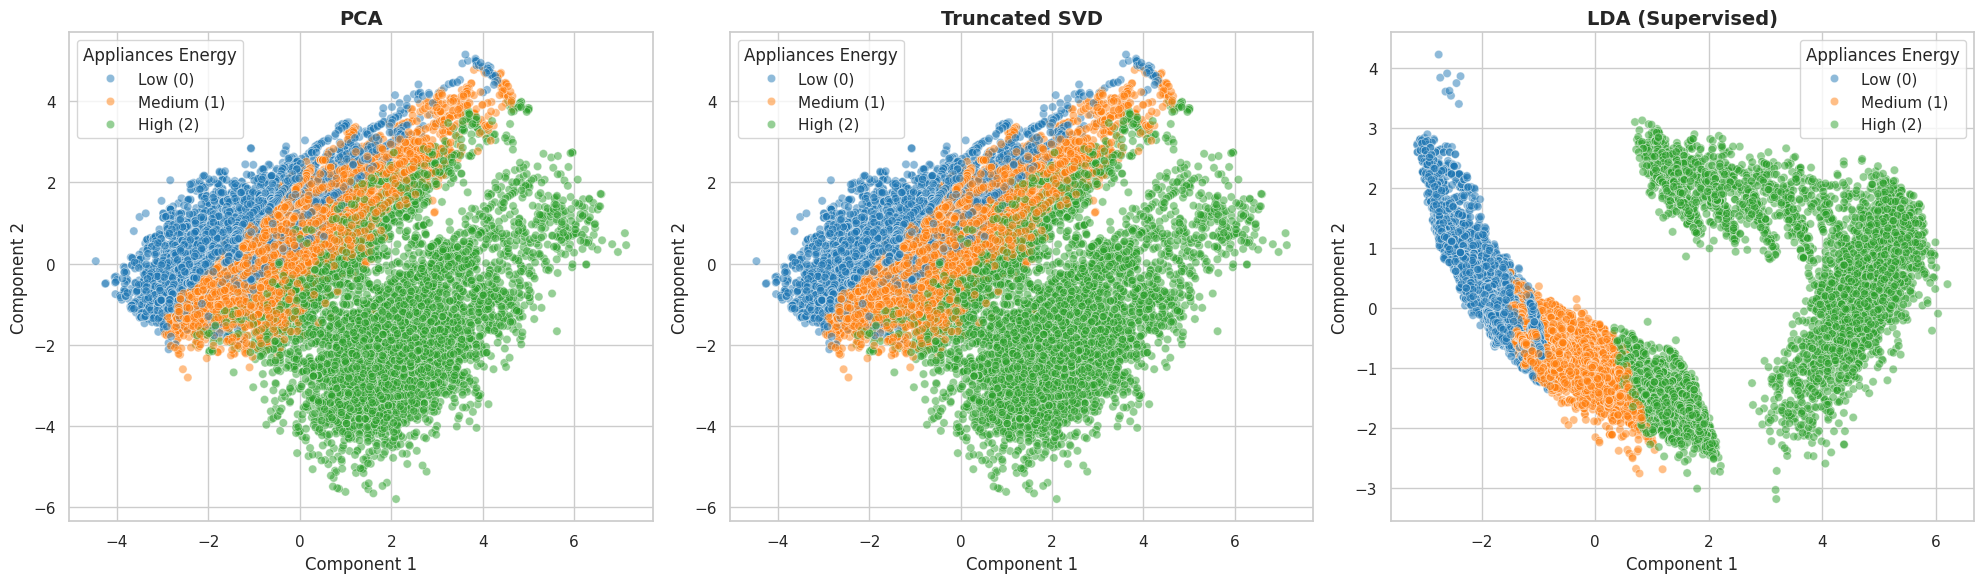

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def plot_2d_space(X_reduced, y, title, ax):
    sns.scatterplot(
        x=X_reduced[:, 0],
        y=X_reduced[:, 1],
        hue=y,
        palette=['#1f77b4', '#ff7f0e', '#2ca02c'],
        alpha=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Low (0)', 'Medium (1)', 'High (2)'], title="Appliances Energy")

# Gọi hàm vẽ 3 biểu đồ tương ứng
plot_2d_space(X_pca, y_categorical, 'PCA', axes[0])
plot_2d_space(X_svd, y_categorical, 'Truncated SVD', axes[1])
plot_2d_space(X_lda, y_categorical, 'LDA (Supervised)', axes[2])

plt.tight_layout()
plt.show()

### 6. Kết luận:

- **Feature Selection (Lựa chọn đặc trưng):** Việc áp dụng và đối chiếu đa dạng các phương pháp từ Filter (SelectKBest), Embedded (Lasso, Random Forest) đến Wrapper (RFECV) giúp đánh giá tầm quan trọng của các biến một cách toàn diện. Quá trình này đã tinh lọc thành công tập dữ liệu, loại bỏ các biến nhiễu và giữ lại những đặc trưng mang nhiều thông tin dự báo nhất.
- **Dimensionality Reduction (PCA, SVD, LDA):**
   - **PCA & SVD (Không giám sát):** Bảo toàn cấu trúc phân bố tự nhiên của dữ liệu, qua đó trực quan hóa được sự chuyển biến liên tục từ mức tiêu thụ năng lượng Thấp (Low) đến Cao (High).
   - **LDA (Có giám sát):** Nhờ tận dụng thông tin nhãn phân loại, thuật toán đã kéo giãn không gian và giúp phân tách nhóm có mức tiêu thụ năng lượng Cao (High) rõ rệt và sắc nét hơn hẳn trong mặt phẳng 2 chiều.